In [49]:
from typing import TypedDict, List, Any
from langgraph.graph import StateGraph ,START,END
import hashlib 
import re
from unstructured.partition.pdf import partition_pdf
from sentence_transformers import SentenceTransformer
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../")))

from qdrant_client.models import PointStruct
from db.qdrant_setup import setup_qdrant

In [50]:

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

path_to_pdf=r"D:\newthings\StructRAG\centOSdepolyment.pdf"

elements = partition_pdf(
    filename=path_to_pdf,
    strategy="fast",
    infer_table_structure=False
)

TYPE_WEIGHTS = {
    "Title": 1.0,
    "NarrativeText": 1.0,
    "ListItem": 0.9,
    "Table": 0.9,
    "Header": 0.8,
    "FigureCaption": 0.6,
    "UncategorizedText": 0.4,
}

client = setup_qdrant(previous_client=globals().get("client"))


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5000.50it/s]
No languages specified, defaulting to English.


test_collection already exists!


In [51]:
class PdfState(TypedDict):
    elements: List[Any]
    structured_data: List[dict]
    chunks: List[dict]
    embeddings: List[List[float]]

In [52]:
def extract_pdf_elements(state: PdfState):

    structured_data = []

    for el in state["elements"]:

        text = str(el).strip()

        if not text:
            continue

        metadata = el.metadata.to_dict()

        structured_data.append({
            "type": el.category,
            "text": text,
            "page": metadata.get("page_number"),
            "filename": metadata.get("filename"),
            "coordinates": metadata.get("coordinates")
        })

    return {
        "structured_data": structured_data
    }

In [53]:
def score(text, types):
    density = sum(
        c.isalnum() or c.isspace()
        for c in text
    ) / max(len(text), 1)

    type_score = max(
        (TYPE_WEIGHTS.get(t, 0.5) for t in types),
        default=0.5
    )

    return round((0.6 * density) + (0.4 * type_score), 3)

In [54]:
def chunk_elements(data, max_chars=400, overlap=80, min_score=0.3):
    chunks = []
    buf = []
    types = set()
    current_heading = None
    page_start = None
    page_end = None
    need_overlap = False

    def flush():
        nonlocal buf, types, page_start, page_end, need_overlap
        if not buf:
            return
        text = " ".join(buf)
        text = re.sub(r"\s+", " ", text).strip()
        sc = score(text, types)
        if sc >= min_score:
            chunks.append({
                "id": hashlib.md5(text.encode()).hexdigest()[:8],
                "text": text,
                "page_start": page_start,
                "page_end": page_end,
                "heading": current_heading,
                "types": list(types),
                "score": sc,
            })
        if need_overlap and overlap > 0:
            overlap_text = text[-overlap:]
            split_idx = overlap_text.find(" ")
            if split_idx != -1:
                overlap_text = overlap_text[split_idx:].strip()
            buf = [overlap_text]
        else:
            buf = []
        types = set()
        page_start = None
        page_end = None
        need_overlap = False

    for el in data:
        text = el.get("text", "").strip()
        if not text:
            continue

        t = el.get("type", "Unknown")

        # ✅ FIX 1: Don't discard Title/Header text — track heading AND buffer it
        if t in ("Title", "Header"):
            current_heading = text
            # Only flush before a new section heading, don't skip the text
            flush()
            buf.append(text)
            types.add(t)
            if page_start is None:
                page_start = el.get("page")
            page_end = el.get("page")
            continue

        if t == "Table":
            flush()
            table_text = re.sub(r"\s+", " ", text)
            chunks.append({
                "id": hashlib.md5(table_text.encode()).hexdigest()[:8],
                "text": table_text,
                "page_start": el.get("page"),
                "page_end": el.get("page"),
                "heading": current_heading,
                "types": ["Table"],
                "score": score(table_text, ["Table"]),
            })
            continue

        if page_start is None:
            page_start = el.get("page")
        page_end = el.get("page")

        current_size = sum(len(x) for x in buf)
        if current_size + len(text) > max_chars:
            need_overlap = True
            flush()
            page_start = el.get("page")
            page_end = el.get("page")

        buf.append(text)
        types.add(t)

    flush()
    return chunks

In [55]:
def chunk_node(state: PdfState):

    data = state["structured_data"]

    chunks = chunk_elements(data)
    return {
        "chunks": chunks
    }


In [56]:
def embed_node(state: PdfState):

    chunks = state["chunks"]
    print("chunks in embded node",state["chunks"])

    texts = [c["text"] for c in chunks]

    embeddings = embed_model.encode(texts)

    # attach embedding to chunks
    for i in range(len(chunks)):
        chunks[i]["embedding"] = embeddings[i].tolist()

    return {
        "chunks": chunks,
        "embeddings": embeddings.tolist()
    }

In [57]:
def qdrant_node(state: PdfState):

    points = []

    for i, chunk in enumerate(state["chunks"]):

        points.append(
            PointStruct(
                id=i,
                vector=chunk["embedding"],
                payload={
                    "text": chunk["text"],
                    "page_start": chunk.get("page_start"),
                    "page_end": chunk.get("page_end"),
                    "heading": chunk.get("heading"),
                    "score": chunk.get("score"),
                }
            )
        )

    client.upsert(
        collection_name="test_collection",
        points=points
    )

    return {"chunks": state["chunks"]}

In [58]:
graph = StateGraph(PdfState)

graph.add_node("extract", extract_pdf_elements)
graph.add_node("chunk", chunk_node)
graph.add_node("embed", embed_node)
graph.add_node("qdrant", qdrant_node)

graph.add_edge(START, "extract")
graph.add_edge("extract", "chunk")
graph.add_edge("chunk", "embed")
graph.add_edge("embed", "qdrant")
graph.add_edge("qdrant", END)

app = graph.compile()

In [59]:
result = app.invoke({
    "elements": elements,
    "structured_data": [],
    "chunks": [],
    "embeddings": []
})

print(f"✅ Done! Inserted {len(result['chunks'])} chunks into Qdrant.")

chunks in embded node [{'id': '864a57ae', 'text': 'Centos OS deployment of Django', 'page_start': 1, 'page_end': 1, 'heading': 'and Apache', 'types': ['Title'], 'score': 1.0}, {'id': '9ca41d47', 'text': 'and Apache Step-1 Update the system and install Apache and mod_wsgi:', 'page_start': 1, 'page_end': 1, 'heading': 'CentOS/Red Hat: bash Copy code', 'types': ['Title', 'NarrativeText'], 'score': 0.974}, {'id': '544ca463', 'text': 'CentOS/Red Hat: bash Copy code', 'page_start': 1, 'page_end': 1, 'heading': 'sudo yum install httpd mod_wsgi python3 -y', 'types': ['Title'], 'score': 0.96}, {'id': 'c7a68cc1', 'text': 'sudo yum install httpd mod_wsgi python3 -y', 'page_start': 1, 'page_end': 1, 'heading': 'Step-2', 'types': ['Title'], 'score': 0.971}, {'id': '88857bdf', 'text': 'Step-2', 'page_start': 1, 'page_end': 1, 'heading': 'cd home mkdir directory_name cd mkdir directory_name', 'types': ['Title'], 'score': 0.9}, {'id': 'b84186ed', 'text': 'cd home mkdir directory_name cd mkdir director

✅ Done! Inserted 34 chunks into Qdrant.


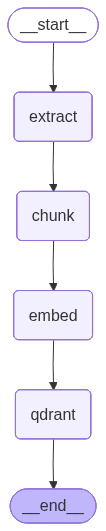

In [60]:
from IPython.display import Image ,display
display(Image(app.get_graph().draw_mermaid_png()))